# Who Lives There? A Look at the Tiny Life in Boyce Park Pond Water
**CMU Pre-College Computational Biology, Module 2 Project**
**Group A3 (Alphas):** Thomas Yu, Thomas Kellog, Lexi Dai, Sarah Wu

## The short version
We studied the water from a pond in **Boyce Park**, a county park built on land that used to be coal mining country. The big question the project asks us is simple: the pond looks pretty and scenic, but is it actually healthy, or is old mine runoff quietly shaping the life inside it?

To find out, we look at the **bacteria and algae living in the water**. Every bacterium carries a kind of ID tag in its DNA (a gene called 16S). A lab already read those ID tags for us and handed us tidy files with the results. Our job is to figure out **who is living in the pond, whether we can trust those IDs, and how this pond compares to the city rivers**, and then explain what it all means.

## What this notebook does, in order
0. Load the files the lab gave us.
1. Identify the most common living things ourselves, using a DNA search tool called BLAST.
2. Compare our answers to the lab's answers, and check for contamination.
3. Make simple charts of what lives in the pond.
4. Make two comparison pictures: our pond next to the rivers, and our own sampling spots next to each other.
5. Tell the story of what we found.
6. Explain, in plain terms, every tool we used.

*A quick note on how to read the results: a name for a whole family or group is usually solid, but a guess at an exact species from this kind of data is shaky. So we trust the broad names more than the very specific ones, and we say so when a guess is uncertain.*


## Step 0: Load the data

In [1]:
# Google Colab already has the number and chart tools we need.
# The one extra tool (Biopython) is only used if you re-run the DNA search live.
!pip -q install biopython

import os, io, csv, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 90)
print("ready")


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


ready


### Tell the notebook where the data is
The data is two folders in our shared Google Drive: our pond (`House1_Boyce_Park_2025`) and a shared set that has every other site including the rivers and the clean water controls (`Baseline_AllSamples_2025`). Run the next cell, let Google Drive connect, and set `DATA_ROOT` to the folder that holds those two folders.

In [2]:
# Find the data. If the two folders are already here (for example you cloned the
# GitHub repo, which includes them in a data folder), just use them. Otherwise
# connect Google Drive.
DATA_ROOT = None
for place in ['.', 'data']:
    if os.path.exists(os.path.join(place, 'House1_Boyce_Park_2025', 'feature-table.tsv')):
        DATA_ROOT = place; break
if DATA_ROOT is None:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        DATA_ROOT = '/content/drive/MyDrive/Taxonomic Project Data'   # change this to your folder
    except Exception:
        DATA_ROOT = '.'

BP   = os.path.join(DATA_ROOT, 'House1_Boyce_Park_2025')
BASE = os.path.join(DATA_ROOT, 'Baseline_AllSamples_2025')
ok = os.path.exists(os.path.join(BP, 'feature-table.tsv'))
print('Our pond folder :', BP, '| found:', ok)
print('Shared folder   :', BASE, '| found:', os.path.exists(os.path.join(BASE, 'feature-table.tsv')))
assert ok, 'Could not find the pond folder. Fix DATA_ROOT above so it points to your Drive folder.'


Our pond folder : data\House1_Boyce_Park_2025 | found: True
Shared folder   : data\Baseline_AllSamples_2025 | found: True


### A few helper functions
These just open the lab's files and hand us the numbers in an easy shape. Nothing clever is happening here.

In [3]:
def load_table(folder):
    # the counts file: rows are microbes, columns are water samples, numbers are how many we saw
    df = pd.read_csv(os.path.join(folder, 'feature-table.tsv'), sep='\t', skiprows=1, dtype=str)
    df = df.rename(columns={df.columns[0]: 'feature_id'})
    if 'taxonomy' in df.columns:
        df = df.drop(columns=['taxonomy'])
    return df.set_index('feature_id').astype(float)

def load_taxonomy(folder):
    # the lab's name for each microbe, plus how sure it was
    t = pd.read_csv(os.path.join(folder, 'taxonomy.tsv'), sep='\t', dtype=str)
    t.columns = ['feature_id', 'taxon', 'confidence'][:len(t.columns)]
    return t.set_index('feature_id')

def load_mapping(folder):
    # which sample came from which spot
    m = pd.read_csv(os.path.join(folder, 'mapping_file.txt'), sep='\t', dtype=str)
    return m.rename(columns={m.columns[0]: 'SampleID'}).set_index('SampleID')

def load_fasta(folder):
    # the actual DNA ID tags we can look up
    seqs, fid = {}, None
    for line in open(os.path.join(folder, 'dna-sequences.fasta')):
        line = line.strip()
        if line.startswith('>'): fid = line[1:].split()[0]; seqs[fid] = ''
        elif fid: seqs[fid] += line
    return seqs

def rank_of(taxon, prefix):
    # pull one level of the name out of the lab's label (like the group name or the genus)
    if not isinstance(taxon, str): return None
    for part in taxon.split(';'):
        part = part.strip()
        if part.startswith(prefix):
            v = part[len(prefix):].strip()
            return v or None
    return None

# open the files for our pond and for the shared set
bp   = load_table(BP);   btax = load_taxonomy(BP);   bmap = load_mapping(BP);   bseq = load_fasta(BP)
base = load_table(BASE); basetax = load_taxonomy(BASE); basemap = load_mapping(BASE)

# label each of our samples by its sampling spot (BP1, BP2, BP4, BP5)
bmap['spot'] = bmap['TreatmentGroup'].map(lambda tg: 'BP' + tg.strip().split()[-1])
samples = list(bp.columns)
print('Our pond has', len(samples), 'water samples and', bp.shape[0], 'kinds of microbe.')
print('Total DNA reads:', int(bp.values.sum()))
print('\nHow many samples per spot:')
print(bmap['spot'].value_counts().to_string())

Our pond has 10 water samples and 5818 kinds of microbe.
Total DNA reads: 882619

How many samples per spot:
spot
BP2    3
BP4    3
BP1    2
BP5    2


## Step 1: Identify the community ourselves

We can't look up thousands of microbes by hand, so we sort them by how common they are and take the **top 20**. Those 20 make up about two thirds of everything in the pond, so they tell most of the story.

For each of the 20 we take its DNA ID tag and run it through **BLAST**, a free online tool from the NIH. BLAST compares our tag to a giant library of known DNA and tells us the closest match. This is the same "search and score" idea we built by hand in the aligner project, just at full scale.

In [4]:
# sort microbes by how common they are and take the top 20
totals = bp.sum(axis=1).sort_values(ascending=False)
top20_ids = list(totals.head(20).index)
grand = totals.sum()

top20 = pd.DataFrame({
    'feature_id': top20_ids,
    'total_reads': totals[top20_ids].astype(int).values,
    'percent_of_pond': (100*totals[top20_ids]/grand).round(2).values,
    'lab_name': btax['taxon'].reindex(top20_ids).values,
    'lab_confidence': btax['confidence'].reindex(top20_ids).astype(float).round(3).values,
})
top20.index = range(1, 21); top20.index.name = 'rank'
print('The top 20 make up', round(top20['percent_of_pond'].sum(), 1), 'percent of the whole pond.')
top20[['feature_id','percent_of_pond','lab_confidence','lab_name']]

The top 20 make up 66.1 percent of the whole pond.


,feature_id,percent_of_pond,lab_confidence,lab_name
rank,,,,
1,821495,34.34,0.997,d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Burkholderiales
2,4402734,10.75,1.000,d__Bacteria; p__Cyanobacteria; c__Cyanobacteriia; o__Chloroplast; f__Chloroplast; g__C...
3,550329,5.86,1.000,d__Bacteria; p__Cyanobacteria; c__Cyanobacteriia; o__Chloroplast; f__Chloroplast; g__C...
4,4203120,2.31,1.000,d__Bacteria; p__Actinobacteriota; c__Acidimicrobiia; o__uncultured; f__uncultured; g__...
5,4327233,1.97,0.999,d__Bacteria; p__Actinobacteriota; c__Actinobacteria; o__Micrococcales; f__Microbacteri...
6,254922,1.84,0.813,d__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__Acetobacterales; f__Acetoba...
7,1140775,1.15,0.996,d__Bacteria; p__Actinobacteriota; c__Acidimicrobiia; o__uncultured; f__uncultured; g__...
8,283765,0.97,0.917,d__Bacteria; p__Actinobacteriota; c__Actinobacteria; o__Micrococcales; f__Micrococcace...
9,13505,0.94,1.000,d__Bacteria; p__Actinobacteriota; c__Acidimicrobiia; o__uncultured; f__uncultured; g__...


In [5]:
# save the 20 DNA tags to a file, which is what BLAST reads
with open('top20.fasta', 'w') as f:
    for fid in top20_ids:
        f.write('>' + fid + '\n' + bseq[fid] + '\n')
print('Saved 20 DNA tags to top20.fasta')

Saved 20 DNA tags to top20.fasta


### Running BLAST: saved results, or live
Looking up 20 tags online takes a while and the NIH server can be busy, so we **saved our results right in this notebook**. It loads them instantly. If you want to redo the lookups yourself, set `RUN_BLAST_LIVE = True` and the same code that made our saved results will run live.

In [6]:
RUN_BLAST_LIVE = False   # set to True to look the 20 tags up online again

def blast_top20():
    from Bio.Blast import NCBIWWW, NCBIXML
    skip = ('uncultured','environmental','metagenome','unidentified','bacterium clone','unknown')
    rows = []
    for i, fid in enumerate(top20_ids, 1):
        h = NCBIWWW.qblast('blastn','nt', bseq[fid], hitlist_size=15, megablast=True)
        rec = NCBIXML.read(io.StringIO(h.read())); h.close()
        def row(a):
            hsp=a.hsps[0]
            return (a.accession, a.hit_def.split('>')[0].strip(),
                    round(100*hsp.identities/hsp.align_length,2), '%.1e'%hsp.expect)
        if rec.alignments:
            top = row(rec.alignments[0])
            named = next((row(a) for a in rec.alignments
                          if not any(s in a.hit_def.lower() for s in skip)), top)
        else:
            top = ('','no match',0.0,''); named = top
        rows.append([i, fid, *top, named[0], named[1], named[2]])
        print(i, fid, top[2], top[1][:45])
    cols = ['rank','feature_id','top_accession','top_match','top_percent_match','top_evalue',
            'named_accession','named_match','named_percent_match']
    return pd.DataFrame(rows, columns=cols)

# our saved BLAST results:
CACHED_BLAST_TSV = r'''rank	feature_id	top_accession	top_hit_def	top_pident	top_evalue	top_bitscore	named_accession	named_hit_def	named_pident
1	821495	JF817232	Uncultured bacterium clone Bac-1-78 16S ribosomal RNA gene, partial sequence	99.14	0.0e+00	837.7	KC677654	Ferrovum sp. PN-J174 16S ribosomal RNA gene, partial sequence	99.14
2	4402734	KC683316	Uncultured bacterium clone F27 16S ribosomal RNA gene, partial sequence	99.32	0.0e+00	804.4	NC_024928	Eunotia naegelii chloroplast, complete genome	99.32
3	550329	FJ612436	Uncultured bacterium clone DP10.5.15 16S ribosomal RNA gene, partial sequence	97.51	0.0e+00	756.4	LC648951	Cryptomonas curvata NIES-281 chloroplast DNA, complete genome	96.83
4	4203120	HQ420135	Uncultured bacterium clone LRE22B39 16S ribosomal RNA gene, partial sequence	99.32	0.0e+00	800.7	HQ420135	Uncultured bacterium clone LRE22B39 16S ribosomal RNA gene, partial sequence	99.32
5	4327233	OR144289	Curtobacterium citreum strain CvEBI-9 16S ribosomal RNA gene, partial sequence	99.33	0.0e+00	806.3	OR144289	Curtobacterium citreum strain CvEBI-9 16S ribosomal RNA gene, partial sequence	99.33
6	254922	NR_159185	Acidocella aquatica strain Ok2G 16S ribosomal RNA, partial sequence	99.09	0.0e+00	791.5	NR_159185	Acidocella aquatica strain Ok2G 16S ribosomal RNA, partial sequence	99.09
7	1140775	GU557032	Uncultured bacterium isolate DGGE gel band pta1A-70 16S ribosomal RNA gene, partial sequence	99.32	0.0e+00	800.7	GU557032	Uncultured bacterium isolate DGGE gel band pta1A-70 16S ribosomal RNA gene, partial sequence	99.32
8	283765	JF107358	Uncultured bacterium clone ncd1277e03c1 16S ribosomal RNA gene, partial sequence	99.55	0.0e+00	811.8	MW547171	Kocuria sp. strain S1_16.1.3 16S ribosomal RNA gene, partial sequence	99.33
9	13505	X92701	Uncultured Actinomycetales bacterium 16S ribosomal RNA (clone TM177)	99.32	0.0e+00	800.7	X92701	Uncultured Actinomycetales bacterium 16S ribosomal RNA (clone TM177)	99.32
10	3538	NC_082073	Klebsormidium nitens strain MVSP plastid, complete genome	99.34	0.0e+00	821.0	NC_082073	Klebsormidium nitens strain MVSP plastid, complete genome	99.34
11	219317	DQ906069	Uncultured bacterium clone ERF-C9 16S ribosomal RNA gene, partial sequence	99.32	0.0e+00	800.7	DQ906069	Uncultured bacterium clone ERF-C9 16S ribosomal RNA gene, partial sequence	99.32
12	647790	EF221487	Uncultured alpha proteobacterium clone SI-1M_F10 16S ribosomal RNA gene, partial sequence	99.32	0.0e+00	797.0	EF221487	Uncultured alpha proteobacterium clone SI-1M_F10 16S ribosomal RNA gene, partial sequence	99.32
13	1113279	KC619579	Uncultured bacterium clone CN4m-bac_e6 16S ribosomal RNA gene, partial sequence	99.32	0.0e+00	797.0	KC924950	Acidiphilium rubrum strain Colony12 16S ribosomal RNA gene, partial sequence	99.32
14	683891	JQ385613	Uncultured bacterium clone MD10h7_267 16S ribosomal RNA gene, partial sequence	99.55	0.0e+00	802.6	JQ385613	Uncultured bacterium clone MD10h7_267 16S ribosomal RNA gene, partial sequence	99.55
15	4203118	KF581207	Uncultured bacterium clone CAMD_CTRL_B1B6 16S ribosomal RNA gene, partial sequence	98.64	0.0e+00	780.4	KF581207	Uncultured bacterium clone CAMD_CTRL_B1B6 16S ribosomal RNA gene, partial sequence	98.64
16	1047041	GQ058319	Uncultured bacterium clone nbw1079b05c1 16S ribosomal RNA gene, partial sequence	99.55	0.0e+00	811.8	GQ058319	Uncultured bacterium clone nbw1079b05c1 16S ribosomal RNA gene, partial sequence	99.55
17	1121839	LK024969	Uncultured bacterium partial 16S rRNA gene, clone BProP8A06	99.32	0.0e+00	797.0	LK024969	Uncultured bacterium partial 16S rRNA gene, clone BProP8A06	99.32
18	4453684	HE604017	Uncultured bacterium partial 16S rRNA gene, clone Central-Bottom-cDNA_clone5	99.14	0.0e+00	837.7	HE604017	Uncultured bacterium partial 16S rRNA gene, clone Central-Bottom-cDNA_clone5	99.14
19	169182	KX956779	Uncultured bacterium clone OTU2432 16S ribosomal RNA gene, partial sequence	99.57	0.0e+00	848.7	CP046022	Enterococcus faecalis strain BFF1B1 chromosome, complete genome	99.57
20	150673	LT721355	Uncultured bacterium partial 16S rRNA gene, clone 108.1_1006040	99.77	0.0e+00	808.1	PV902520	Sphingomonas sp. strain A4e 16S ribosomal RNA gene, partial sequence	99.32
'''

if RUN_BLAST_LIVE:
    blast = blast_top20()
    blast.to_csv('top20_blast_results.tsv', sep='\t', index=False)
else:
    blast = pd.read_csv(io.StringIO(CACHED_BLAST_TSV), sep='\t')
# use friendly column names no matter which way the results were made
blast = blast.rename(columns={'top_hit_def':'top_match','top_pident':'top_percent_match',
                              'named_hit_def':'named_match','named_pident':'named_percent_match'})
blast['feature_id'] = blast['feature_id'].astype(str)   # make the IDs match the counts file
# "top match" is the very closest DNA, "named match" is the closest one with a real organism name
blast[['rank','feature_id','top_percent_match','top_match','named_match']]

,rank,feature_id,top_percent_match,top_match,named_match
0,1,821495,99.14,"Uncultured bacterium clone Bac-1-78 16S ribosomal RNA gene, partial sequence","Ferrovum sp. PN-J174 16S ribosomal RNA gene, partial sequence"
1,2,4402734,99.32,"Uncultured bacterium clone F27 16S ribosomal RNA gene, partial sequence","Eunotia naegelii chloroplast, complete genome"
2,3,550329,97.51,"Uncultured bacterium clone DP10.5.15 16S ribosomal RNA gene, partial sequence","Cryptomonas curvata NIES-281 chloroplast DNA, complete genome"
3,4,4203120,99.32,"Uncultured bacterium clone LRE22B39 16S ribosomal RNA gene, partial sequence","Uncultured bacterium clone LRE22B39 16S ribosomal RNA gene, partial sequence"
4,5,4327233,99.33,"Curtobacterium citreum strain CvEBI-9 16S ribosomal RNA gene, partial sequence","Curtobacterium citreum strain CvEBI-9 16S ribosomal RNA gene, partial sequence"
5,6,254922,99.09,"Acidocella aquatica strain Ok2G 16S ribosomal RNA, partial sequence","Acidocella aquatica strain Ok2G 16S ribosomal RNA, partial sequence"
6,7,1140775,99.32,"Uncultured bacterium isolate DGGE gel band pta1A-70 16S ribosomal RNA gene, partial se...","Uncultured bacterium isolate DGGE gel band pta1A-70 16S ribosomal RNA gene, partial se..."
7,8,283765,99.55,"Uncultured bacterium clone ncd1277e03c1 16S ribosomal RNA gene, partial sequence","Kocuria sp. strain S1_16.1.3 16S ribosomal RNA gene, partial sequence"
8,9,13505,99.32,Uncultured Actinomycetales bacterium 16S ribosomal RNA (clone TM177),Uncultured Actinomycetales bacterium 16S ribosomal RNA (clone TM177)
9,10,3538,99.34,"Klebsormidium nitens strain MVSP plastid, complete genome","Klebsormidium nitens strain MVSP plastid, complete genome"


## Step 2: Check our answers, and check for contamination

Now we do two honesty checks.

First, we put **our BLAST names next to the lab's names**. Where they agree, great. Where they differ, it is usually because BLAST could name the exact organism while the lab only got to a broad group. Our best example: the single most common microbe in the pond. The lab only labeled it a broad group ("Burkholderiales"), but our BLAST pins it to **Ferrovum**, an iron eating bacterium that is a classic sign of mine drainage.

In [7]:
# put the lab name and our BLAST name side by side
def genus(t): return rank_of(t, 'g__')
recon = top20[['feature_id','percent_of_pond','lab_confidence','lab_name']].copy()
recon['lab_genus'] = recon['lab_name'].map(genus)
recon = recon.merge(blast[['feature_id','top_percent_match','top_match','named_match','named_percent_match']],
                    on='feature_id', how='left')
def compare(row):
    g = row['lab_genus']
    if not isinstance(g, str): return 'lab gave no exact name'
    return 'agree' if g.split('_')[0].lower() in str(row['named_match']).lower() else 'BLAST names it more exactly'
recon['comparison'] = recon.apply(compare, axis=1)
recon.index = range(1,21); recon.index.name='rank'
recon[['percent_of_pond','lab_confidence','lab_genus','named_match','named_percent_match','comparison']]

,percent_of_pond,lab_confidence,lab_genus,named_match,named_percent_match,comparison
rank,,,,,,
1,34.34,0.997,NaN,"Ferrovum sp. PN-J174 16S ribosomal RNA gene, partial sequence",99.14,lab gave no exact name
2,10.75,1.000,Chloroplast,"Eunotia naegelii chloroplast, complete genome",99.32,agree
3,5.86,1.000,Chloroplast,"Cryptomonas curvata NIES-281 chloroplast DNA, complete genome",96.83,agree
4,2.31,1.000,uncultured,"Uncultured bacterium clone LRE22B39 16S ribosomal RNA gene, partial sequence",99.32,agree
5,1.97,0.999,NaN,"Curtobacterium citreum strain CvEBI-9 16S ribosomal RNA gene, partial sequence",99.33,lab gave no exact name
6,1.84,0.813,Acidocella,"Acidocella aquatica strain Ok2G 16S ribosomal RNA, partial sequence",99.09,agree
7,1.15,0.996,uncultured,"Uncultured bacterium isolate DGGE gel band pta1A-70 16S ribosomal RNA gene, partial se...",99.32,agree
8,0.97,0.917,Kocuria,"Kocuria sp. strain S1_16.1.3 16S ribosomal RNA gene, partial sequence",99.33,agree
9,0.94,1.000,uncultured,Uncultured Actinomycetales bacterium 16S ribosomal RNA (clone TM177),99.32,agree


### Check the clean water controls for contamination
When the lab runs samples, it also runs a few bottles of **pure, clean water** through the exact same machines. Nothing should show up in those. If something does, it sneaked in from handling, gloves, or the kit chemicals, and it is not really from the pond. Anything that is common in those clean water bottles gets flagged as contamination.

In [8]:
controls = [s for s in base.columns if basemap.loc[s,'TreatmentGroup']=='Water Control']
print('Clean water control samples:', controls)
print('Reads in each control:', {c:int(base[c].sum()) for c in controls})

# for each of our top 20, how many reads showed up in the clean water controls?
ctrl_reads = {fid:(int(base.loc[fid,controls].sum()) if fid in base.index else 0) for fid in top20_ids}
ctrl_total = sum(int(base[c].sum()) for c in controls)

trust = recon[['feature_id','percent_of_pond','lab_genus','named_match']].copy()
trust['reads_in_controls'] = [ctrl_reads[f] for f in top20_ids]
trust['percent_of_controls'] = (100*trust['reads_in_controls']/ctrl_total).round(2)
def call(r):
    if r['percent_of_controls'] >= 1.0: return 'CONTAMINATION (also common in blanks)'
    if r['percent_of_controls'] > 0.1:  return 'tiny bit in blanks'
    return 'clean, trustworthy'
trust['verdict'] = trust.apply(call, axis=1)
trust.index = range(1,21); trust.index.name='rank'
trust

Clean water control samples: ['C9SKTRC', 'C12TPTRC']
Reads in each control: {'C9SKTRC': 87829, 'C12TPTRC': 66423}


,feature_id,percent_of_pond,lab_genus,named_match,reads_in_controls,percent_of_controls,verdict
rank,,,,,,,
1,821495,34.34,NaN,"Ferrovum sp. PN-J174 16S ribosomal RNA gene, partial sequence",281,0.18,tiny bit in blanks
2,4402734,10.75,Chloroplast,"Eunotia naegelii chloroplast, complete genome",719,0.47,tiny bit in blanks
3,550329,5.86,Chloroplast,"Cryptomonas curvata NIES-281 chloroplast DNA, complete genome",0,0.00,"clean, trustworthy"
4,4203120,2.31,uncultured,"Uncultured bacterium clone LRE22B39 16S ribosomal RNA gene, partial sequence",0,0.00,"clean, trustworthy"
5,4327233,1.97,NaN,"Curtobacterium citreum strain CvEBI-9 16S ribosomal RNA gene, partial sequence",0,0.00,"clean, trustworthy"
6,254922,1.84,Acidocella,"Acidocella aquatica strain Ok2G 16S ribosomal RNA, partial sequence",0,0.00,"clean, trustworthy"
7,1140775,1.15,uncultured,"Uncultured bacterium isolate DGGE gel band pta1A-70 16S ribosomal RNA gene, partial se...",0,0.00,"clean, trustworthy"
8,283765,0.97,Kocuria,"Kocuria sp. strain S1_16.1.3 16S ribosomal RNA gene, partial sequence",14518,9.41,CONTAMINATION (also common in blanks)
9,13505,0.94,uncultured,Uncultured Actinomycetales bacterium 16S ribosomal RNA (clone TM177),0,0.00,"clean, trustworthy"


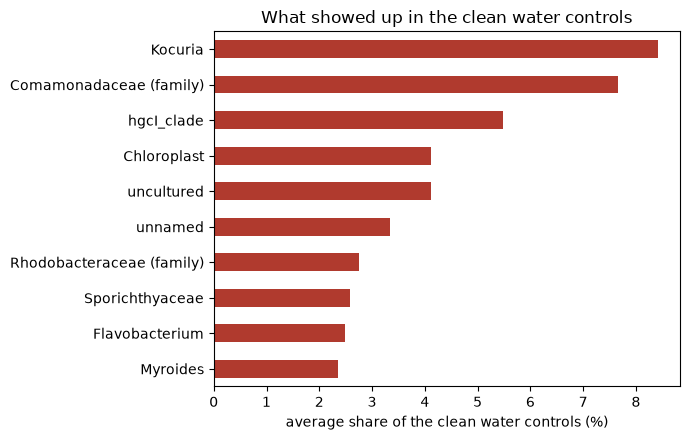

In [9]:
# what is common in the clean water controls? (skin and kit bacteria should show up)
btx = basetax['taxon']
best = btx.map(lambda t: rank_of(t,'g__') or ((rank_of(t,'f__')+' (family)') if rank_of(t,'f__') else 'unnamed'))
crel = base[controls].div(base[controls].sum(axis=0), axis=1)
ctrl_taxa = crel.groupby(best.reindex(base.index).values).sum().mean(axis=1).sort_values(ascending=False).head(10)
ax = (ctrl_taxa*100)[::-1].plot.barh(figsize=(7,4.5), color='#b03a2e')
ax.set_xlabel('average share of the clean water controls (%)')
ax.set_title('What showed up in the clean water controls')
plt.tight_layout(); plt.show()

## Step 3: What actually lives in the pond

Now we add up the counts to see the makeup of the community. The first chart groups microbes into big families and shows how that mix changes across our four sampling spots. The second chart shows the most common individual types overall.

We use **shares (percentages)** instead of raw counts so that samples with more total reads do not look bigger just because more DNA was read.

Biggest families across the whole pond (average share, %):
Proteobacteria      51.6
Cyanobacteria       20.0
Actinobacteriota    14.5
Acidobacteriota      3.3
Patescibacteria      3.1
Bacteroidota         2.3
Planctomycetota      0.8
Chloroflexi          0.8


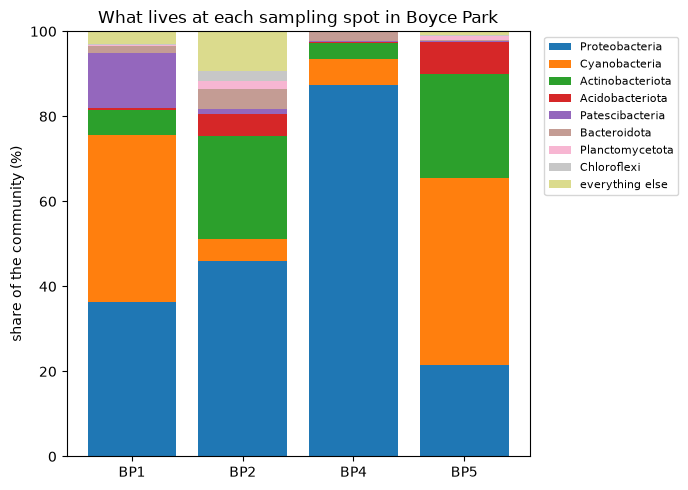

In [10]:
# turn counts into shares within each sample
rel = bp.div(bp.sum(axis=0), axis=1)
phy = btax['taxon'].reindex(bp.index).map(lambda t: rank_of(t,'p__') or 'unnamed')
phy_by_sample = rel.groupby(phy.values).sum()
phy_mean = phy_by_sample.mean(axis=1).sort_values(ascending=False)
print('Biggest families across the whole pond (average share, %):')
print((phy_mean.head(8)*100).round(1).to_string())

spot_order=['BP1','BP2','BP4','BP5']
phy_spot = pd.DataFrame({sp: phy_by_sample[[s for s in samples if bmap.loc[s,'spot']==sp]].mean(axis=1)
                         for sp in spot_order})
topP = list(phy_mean.head(8).index)
plot_df = phy_spot.reindex(topP).fillna(0); plot_df.loc['everything else'] = (1-plot_df.sum()).clip(lower=0)

fig,ax=plt.subplots(figsize=(7,5)); bottom=np.zeros(len(spot_order))
for i,p in enumerate(plot_df.index):
    ax.bar(spot_order, plot_df.loc[p]*100, bottom=bottom, label=p, color=plt.cm.tab20(i/max(1,len(plot_df))))
    bottom += (plot_df.loc[p]*100).values
ax.set_ylabel('share of the community (%)'); ax.set_ylim(0,100)
ax.set_title('What lives at each sampling spot in Boyce Park')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8); plt.tight_layout(); plt.show()

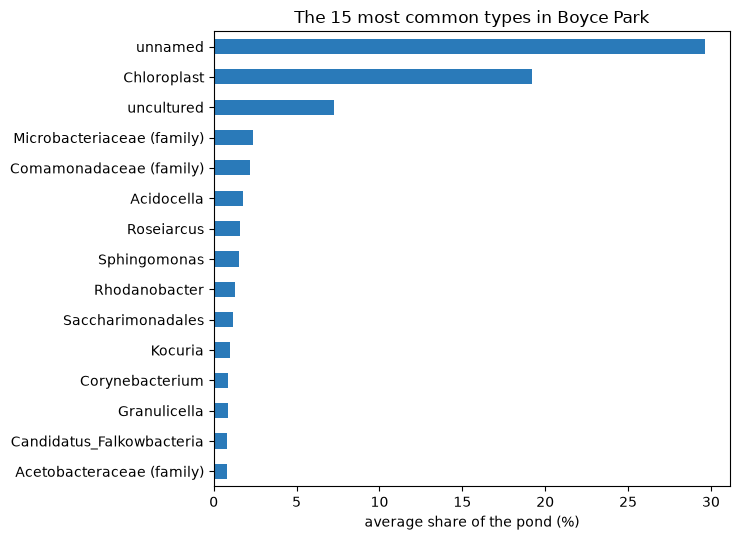

In [11]:
# the most common individual types overall
fam = btax['taxon'].reindex(bp.index)
bestg = fam.map(lambda t: rank_of(t,'g__') or ((rank_of(t,'f__')+' (family)') if rank_of(t,'f__') else 'unnamed'))
gen_mean = rel.groupby(bestg.values).sum().mean(axis=1).sort_values(ascending=False).head(15)
ax=(gen_mean*100)[::-1].plot.barh(figsize=(7.5,5.5), color='#2a7ab9')
ax.set_xlabel('average share of the pond (%)')
ax.set_title('The 15 most common types in Boyce Park')
plt.tight_layout(); plt.show()

## Step 4: Two comparison pictures

To compare whole communities we make a kind of **similarity map**. Each dot is one water sample. Samples with similar life sit close together; samples with different life sit far apart. (Under the hood this scores how different every pair of samples is, then lays them out on a 2D map.)

**Picture A** puts our pond next to the rivers and the other sites.
**Picture B** zooms in on just our own pond, colored by sampling spot.

In [12]:
def difference_scores(mat):
    # for every pair of samples, a 0 to 1 score of how different they are
    n=mat.shape[0]; D=np.zeros((n,n)); rs=mat.sum(1)
    for i in range(n):
        for j in range(i+1,n):
            den=rs[i]+rs[j]; d=(np.abs(mat[i]-mat[j]).sum()/den) if den else 0.0
            D[i,j]=D[j,i]=d
    return D

def make_map(D):
    # turn the difference scores into 2D dots for the map
    n=D.shape[0]; A=-0.5*D**2; J=np.eye(n)-np.ones((n,n))/n; B=J@A@J
    val,vec=np.linalg.eigh(B); idx=np.argsort(val)[::-1]; val,vec=val[idx],vec[:,idx]
    pos=val>1e-9; return vec[:,pos]*np.sqrt(val[pos]), val[pos]/val[pos].sum()

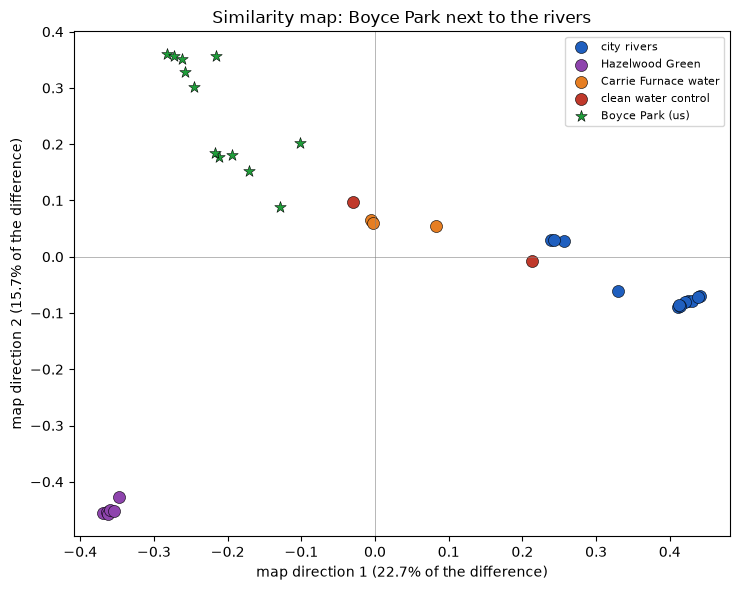

In [13]:
# Picture A: our pond next to the rivers and other water sites
water=[s for s in base.columns if basemap.loc[s,'TreatmentGroup'].startswith('Water') or basemap.loc[s,'TreatmentGroup']=='Uncategorized']
def group_of(s):
    tg=basemap.loc[s,'TreatmentGroup']
    if 'Boyce' in tg or tg=='Uncategorized': return 'Boyce Park (us)'
    if tg in ('Water Point Allegheny','Water Point Monongahela','Water Ohio','Water Braddock'): return 'city rivers'
    if tg=='Water Hazelwood Green': return 'Hazelwood Green'
    if tg=='Water Carrie Furnace': return 'Carrie Furnace water'
    if tg=='Water Control': return 'clean water control'
    return 'other water'
coords,share=make_map(difference_scores(base[water].T.values))
groups=[group_of(s) for s in water]
col={'Boyce Park (us)':'#1f9e3a','city rivers':'#1f5fbf','Hazelwood Green':'#8e44ad','Carrie Furnace water':'#e67e22','clean water control':'#c0392b','other water':'#7f8c8d'}
fig,ax=plt.subplots(figsize=(7.5,6))
for g in ['city rivers','Hazelwood Green','Carrie Furnace water','clean water control','Boyce Park (us)','other water']:
    ix=[i for i,x in enumerate(groups) if x==g]
    if ix: ax.scatter(coords[ix,0],coords[ix,1],s=75,label=g,c=col[g],edgecolor='k',lw=.4,marker='*' if g.startswith('Boyce') else 'o')
ax.set_xlabel('map direction 1 (' + str(round(share[0]*100,1)) + '% of the difference)')
ax.set_ylabel('map direction 2 (' + str(round(share[1]*100,1)) + '% of the difference)')
ax.set_title('Similarity map: Boyce Park next to the rivers')
ax.legend(fontsize=8); ax.axhline(0,c='grey',lw=.4); ax.axvline(0,c='grey',lw=.4)
plt.tight_layout(); plt.show()

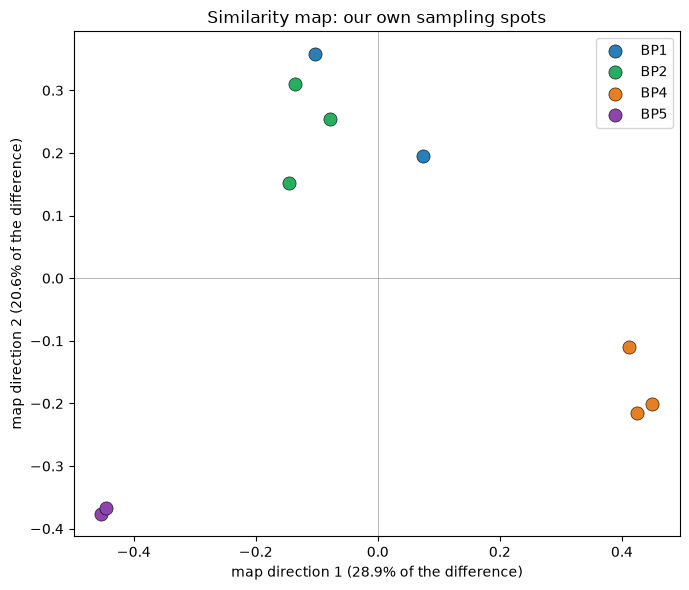

In [14]:
# Picture B: just our pond, colored by sampling spot
coords_b,share_b=make_map(difference_scores(bp[samples].T.values))
spots=[bmap.loc[s,'spot'] for s in samples]
sc={'BP1':'#2980b9','BP2':'#27ae60','BP4':'#e67e22','BP5':'#8e44ad'}
fig,ax=plt.subplots(figsize=(7,6))
for sp in spot_order:
    ix=[i for i,s in enumerate(spots) if s==sp]
    if ix: ax.scatter(coords_b[ix,0],coords_b[ix,1],s=90,label=sp,c=sc[sp],edgecolor='k',lw=.4)
ax.set_xlabel('map direction 1 (' + str(round(share_b[0]*100,1)) + '% of the difference)')
ax.set_ylabel('map direction 2 (' + str(round(share_b[1]*100,1)) + '% of the difference)')
ax.set_title('Similarity map: our own sampling spots')
ax.legend(); ax.axhline(0,c='grey',lw=.4); ax.axvline(0,c='grey',lw=.4)
plt.tight_layout(); plt.show()

## Step 5: The story we found

### Who lives in the pond

Boyce Park pond is not the clean, healthy community you might guess from how it looks. It is run by one iron eating bacterium, with a lot of algae, sitting on top of a crew of acid loving bacteria. That whole mix is the classic fingerprint of **acid mine drainage**, the acidic, iron rich runoff that old coal mines leave behind.


Here are the main characters, in plain terms:


| Living thing | What it is and what it does | What it tells us |
|---|---|---|
| **Ferrovum** | An iron eating bacterium. It makes its living by rusting the iron dissolved in the water, and it only survives in acidic, iron rich water. | It is the single most common thing in the pond (about a third of everything), and it is a well known sign of mine drainage. |
| **Eunotia (an alga)** | A tiny glass shelled alga that lives by photosynthesis, like a plant. This particular kind is famous for living in acidic water, so it backs up the mine drainage story. | The pond really is green and alive, just with acid loving algae. |
| **Acidocella and Acidiphilium** | Acid loving bacteria that feed on bits of leftover organic material. They are classic residents of acidic, iron rich mine water and do not belong in a normal, healthy pond.. | Fits an acidic, mine shaped pond. |
| **Acidimicrobiaceae** | Another acid loving group that helps cycle iron in the water. More support for an acidic, iron rich pond.. | Fits an acidic, mine shaped pond. |
| **Roseiarcus** | An acid loving bacterium usually found in boggy, acidic water. One more vote for acidic conditions.. | Fits an acidic, mine shaped pond. |
| **Rhodanobacter** | A bacterium that copes well with acid and pollution. Seeing a lot of it points to acidic, polluted water.. | Fits an acidic, mine shaped pond. |
| **Kocuria and Lawsonella** | These are skin bacteria, not water bacteria. They got in from handling the samples. | We found them in our clean water controls, so we treat them as contamination and leave them out of the story. |

### What surprised us

The biggest surprise was the number one microbe. The lab only labeled it a broad group, but our own search identified it as **Ferrovum**, an iron eater tied to mine drainage. Some of its closest public matches are even labeled with mine drainage names. So doing the search ourselves found something the automatic pipeline missed.


The second surprise was that even the **algae point to acid**. About a fifth of the pond is algae, and the kinds we found (like the diatom Eunotia) are ones that prefer acidic water. So the pond looks green and healthy, but it is green in an acidic way.


### What these tiny things are doing

A community whose primary producers are iron eating bacteria (Ferrovum) instead of the cyanobacteria and green algae of a normal pond, whose bacteria that eat leftover material are obligate acidophiles that scavenge scarce organic carbon and respire rusted iron iron (Acidiphilium, Acidocella), and whose actinobacterial iron-cyclers (Acidimicrobiaceae) close a tight dissolved iron-rusted iron redox loop, is the textbook biological fingerprint of acid mine drainage. These taxa are physiologically restricted to about pH 2 to 4 and run their metabolism on abundant dissolved dissolved iron iron and sulfate (a mine chemical), so their dominance is a direct living proxy for low pH plus high dissolved iron and sulfate (a mine chemical), the chemistry produced when pyrite (fool's gold, common in coal) in coal-bearing strata is oxidatively weathered. The acidophilic diatom Eunotia corroborates this, being a classic acidification living warning sign that outcompetes normal (not acidic) diatoms only below roughly pH 5 to 5.5. Diagnostically, diversity is also low and skewed toward a few iron and sulfur specialists, because few metabolisms are thermodynamically favorable under such extreme metal-rich acidity (Baker and Banfield 2003; Johnson and Hallberg 2003; Mendez-Garcia et al 2015). In short, the microbiome answers the guiding question bluntly: the water does not live up to its scenic looks, because its residents are being selected by mine-drainage chemistry rather than by a healthy normal (not acidic) pond.


### Being honest about contamination

Our clean water controls were not empty. They picked up skin bacteria (**Kocuria** and **Lawsonella**), so we flagged those as contamination and dropped them. The important part: the mine drainage crew (Ferrovum, the acid lovers, the acid loving algae) barely showed up in the controls at all, so those findings are real and trustworthy.


### The answer to the question

**Is mine drainage shaping who lives in the pond? Yes.** Even though the pond looks scenic, the life inside it is the kind you only find in acidic, iron rich, mine shaped water, and on our comparison map it sits clearly apart from the city rivers. The one thing that would make this airtight is a simple water test for acidity and iron, which we can ask the instructors for.


## Step 6: Every tool we used, in plain terms

- **The lab's files.** A lab read the DNA ID tag (the 16S gene) of the microbes in each water sample, cleaned up the data, and made a best guess at each name. We treat those guesses as a starting point, not the final word.
- **BLAST.** A free NIH tool that takes a piece of DNA and finds its closest match in a huge public library. We used the big general library because the special microbe only library is not available to the automatic version of the tool. We report how close each match is. We trust broad names more than exact species names.
- **The clean water controls.** Bottles of pure water run through the same machines. Anything common in them is contamination, so we removed it (the skin bacteria).
- **Shares instead of raw counts.** We turn counts into percentages so a sample is not judged bigger just because more of its DNA happened to be read.
- **The similarity maps.** We score how different every pair of samples is, then lay the samples out as dots so that similar ones sit close together.
- **About the shared folder.** The set we used has every kind of site in it. For the rivers comparison we used only the water samples from it. There is also a water only version of this set that is the more official choice, and switching to it is a one line change.
- **What we left out on purpose.** The project lists two optional extras (a function predictor called PICRUSt and a statistics test). We left both out to keep this notebook simple and focused on the required steps.

Everything above can be re run from the code in this notebook. We used AI as a helper for writing and code, but we understand and stand behind every step.

## Where our facts come from

These are the main sources behind what we said about each organism.

- Ullrich et al. 2016, PLOS ONE : Genome Analysis of the Acidophilic Iron-Oxidising Strain JA12 Indicates Phylogenetic and Metabolic Diversity within the Novel Genus "Ferrovum" (Betaproteobacteria; chemolithoautotrophy, CO2 fixation, provisional genus, species-level 16S limits) (https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0146832)
- Grettenberger et al. 2020, BMC Microbiology : Metabolic diversity and co-occurrence of multiple Ferrovum species at an acid mine drainage site (AMD pH ~2.1 to 2.4, high Fe(II), multiple co-occurring Ferrovum species, dominance in AMD) (https://bmcmicrobiol.biomedcentral.com/articles/10.1186/s12866-020-01768-w)
- Mühling et al. 2014, Genome Announcements (ASM) : Draft Genome Sequence of the Nominated Type Strain of "Ferrovum myxofaciens" P3G, an Acidophilic, Iron-Oxidizing Betaproteobacterium (EPS/streamer biofilms; Mynydd Parys AMD, Wales) (https://journals.asm.org/doi/10.1128/genomea.00834-14)
- San-Martin-Uriz et al. 2020, mSystems : Insights into the Metabolism and Evolution of the Genus Acidiphilium, a Typical Acidophile in Acid Mine Drainage (https://journals.asm.org/doi/10.1128/msystems.00867-20)
- Bridge & Johnson 2002 (Reduction of ferric iron by acidophilic heterotrophic bacteria: constitutive and inducible enzyme systems in Acidiphilium spp.), PubMed (https://pubmed.ncbi.nlm.nih.gov/11849360/)
- Sievers et al. : Phylogenetic positioning of Acetobacter, Gluconobacter, Rhodopila and Acidiphilium as a branch of acidophilic bacteria in the alpha-subclass of Proteobacteria based on 16S rDNA (https://www.sciencedirect.com/science/article/abs/pii/S0723202011800068)
- LPSN (DSMZ) : Genus Acidocella: taxonomy, type species (A. facilis, Kishimoto et al. 1996), family Acetobacteraceae, species list, isolation from acidic coal-mine drainage, and phylogenomic uncertainty note. (https://lpsn.dsmz.de/genus/acidocella)
- Johnson et al. 2001, Environmental Microbiology : Isolation and phylogenetic characterization of acidophilic microorganisms from acidic drainage at an abandoned copper mine; documents Acidocella facilis-like isolates (~96% 16S identity) as heterotrophic acidophiles in AMD (pH ~2.7-3.7). (https://ami-journals.onlinelibrary.wiley.com/doi/full/10.1046/j.1462-2920.2001.00234.x)
- Méndez-García / González-Toril style review : 'Acidophilic heterotrophs: basic aspects and technological applications,' Frontiers in Microbiology 2024; classifies Acidocella among strictly respiratory acidophilic heterotrophs (O2 as terminal acceptor) and notes A. aromatica metal-nanoparticle/organic-carbon roles. (https://www.frontiersin.org/journals/microbiology/articles/10.3389/fmicb.2024.1374800/full)
- Kulichevskaya IS, et al. (2014) Descriptions of Roseiarcus fermentans gen. nov., sp. nov., a bacteriochlorophyll a-containing fermentative bacterium related phylogenetically to alphaproteobacterial methanotrophs, and of the family Roseiarcaceae fam. nov. Int J Syst Evol Microbiol 64:2558-2565 (original description; morphology, pH/temperature ranges, 16S similarities, bacteriochlorophyll, family erection). (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijs.0.064576-0)
- LPSN (List of Prokaryotic names with Standing in Nomenclature) - Genus Roseiarcus (nomenclature, type species, family Roseiarcaceae, authorship Kulichevskaya et al. 2014). (https://lpsn.dsmz.de/genus/roseiarcus)
- Serkebaeva YM / Dedysh SN et al. (2020) Bacterial Communities of Regressive Spots in Ombrotrophic Bogs: Structure and Functions, Microbiology (Springer) - documents Roseiarcus/Beijerinckiaceae abundance in acidic peat bog/flark habitats (ecological/environmental context). (https://link.springer.com/article/10.1134/S0026261720010063)
- Hordt A, et al. (2024/2023) Refining the taxonomy of the order Hyphomicrobiales (Rhizobiales) based on whole-genome comparisons of >130 type strains, Int J Syst Evol Microbiol - confirms order-level (Hyphomicrobiales/Rhizobiales) placement and notes Roseiarcaceae non-monophyly (Rhodoblastus vs Roseiarcus). (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijsem.0.006328)
- DeNicola, D.M. (2000). A review of diatoms found in highly acidic environments. Hydrobiologia 433:111-122 : establishes Eunotia as a dominant acidobiontic/acidophilous genus of highly acidic and AMD-affected waters. (https://link.springer.com/article/10.1023/A:1004066620172)
- Molecular complexity of the differential growth of freshwater diatoms along pH gradients (2025), PMC : characterizes Eunotia strains as acidophiles with fastest growth at pH ~4.7 and documents the genus's low-pH adaptation. (https://pmc.ncbi.nlm.nih.gov/articles/PMC12145874/)
- American Society for Microbiology : Impact of Acid Mine Drainage (AMD) on diatom populations in a Pennsylvania stream: Eunotia found as the only diatom genus at average pH ~3.4. (https://asm.org/image-gallery/impact-of-acid-mine-drainage-amd-on-diatom-popul)